# Here I want to investigate antibody reactivity to other genera / species

In [1]:
import pandas as pd 

meta = pd.read_csv('lassa_library_sequences_species_standardized_070726_ICTV_corrected.csv')

df = pd.read_csv('long_091826.csv')

In [35]:
species_unique_pep_count = df.groupby('species')['peptide'].nunique().reset_index(name='unique_reactive_peps_in_cohort')

In [ ]:
species_unique_pep_count

In [36]:
reactive_peps_per_species = df.groupby(['species', 'cohort', 'individual']).agg(
    sum_peps_reactive = ('reactive', 'sum'),
).reset_index()

### normalize to library peptides on the individual level

### summary statistics and normalization on a cohort level

In [37]:
reactive_peps_per_species_cohort_summary = reactive_peps_per_species.groupby(['species', 'cohort']).agg(
    mean_cohort_reactive_species_peps = ('sum_peps_reactive', 'mean'), 
    median_cohort_reactive_species_peps = ('sum_peps_reactive', 'median'),
    max_cohort_individual_reactive_species_peps = ('sum_peps_reactive', 'max'), 
    sum_cohort_reactive_species_peps = ('sum_peps_reactive', 'sum'), 
).round(1).reset_index()

In [38]:
meta_number_peps_per_species = meta.groupby('species').size().reset_index(name='number_peps_in_library')

In [39]:
meta_number_peps_per_species.sort_values('number_peps_in_library', ascending=False).head(5)

,species,number_peps_in_library
129,Mammarenavirus lassaense,4494
241,Orthonairovirus haemorrhagiae,2524
119,Mammarenavirus choriomeningitidis,2267
185,Orthoflavivirus denguei,2050
464,unidentified Reptarenavirus,1418


In [40]:
reactive_peps_per_species_cohort_summary = reactive_peps_per_species_cohort_summary.merge(meta_number_peps_per_species, on='species', how='left')
reactive_peps_per_species_cohort_summary = reactive_peps_per_species_cohort_summary.merge(species_unique_pep_count, on='species', how='left')

In [41]:
reactive_peps_per_species_cohort_summary['unique_reactive_peps_in_cohort_normalized_to_library'] = (reactive_peps_per_species_cohort_summary['unique_reactive_peps_in_cohort'] / reactive_peps_per_species_cohort_summary['number_peps_in_library'] * 100).round(1)

In [42]:
reactive_peps_per_species_cohort_summary['mean_perc_cohort_reactive_species_peps_normalized_to_library'] = (reactive_peps_per_species_cohort_summary['mean_cohort_reactive_species_peps'] / reactive_peps_per_species_cohort_summary['number_peps_in_library'] * 100).round(1)

In [43]:
reactive_peps_per_species_cohort_summary.sort_values(by=['mean_cohort_reactive_species_peps', 'max_cohort_individual_reactive_species_peps'], ascending=False).head(20)

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library
181,Mammarenavirus lassaense,SL,7.4,7.0,27,2924,4494,76,1.7,0.2
365,Orthonairovirus haemorrhagiae,SL,3.3,3.0,12,1327,2524,39,1.5,0.1
269,Orthoflavivirus denguei,SL,2.9,3.0,11,1139,2050,32,1.6,0.1
249,Nairoviridae sp.,SL,1.9,2.0,6,759,1160,20,1.7,0.2
167,Mammarenavirus choriomeningitidis,SL,1.8,2.0,7,718,2267,16,0.7,0.1
357,Orthonairovirus erveense,SL,1.3,1.0,8,515,1134,17,1.5,0.1
733,unidentified Reptarenavirus,SL,1.2,1.0,4,474,1418,14,1.0,0.1
191,Mammarenavirus lunaense,SL,1.1,1.0,6,439,684,10,1.5,0.2
649,Trypanosoma cruzi,SL,1.1,1.0,6,443,471,13,2.8,0.2
391,Orthonairovirus nairobiense,SL,1.1,1.0,4,441,333,7,2.1,0.3


## plot the 

In [44]:
reactive_peps_per_species_cohort_summary.sort_values(by=['max_cohort_individual_reactive_species_peps'], ascending=False).head(5)

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library
181,Mammarenavirus lassaense,SL,7.4,7.0,27,2924,4494,76,1.7,0.2
365,Orthonairovirus haemorrhagiae,SL,3.3,3.0,12,1327,2524,39,1.5,0.1
269,Orthoflavivirus denguei,SL,2.9,3.0,11,1139,2050,32,1.6,0.1
357,Orthonairovirus erveense,SL,1.3,1.0,8,515,1134,17,1.5,0.1
167,Mammarenavirus choriomeningitidis,SL,1.8,2.0,7,718,2267,16,0.7,0.1


In [45]:
reactive_peps_per_species_cohort_summary.loc[reactive_peps_per_species_cohort_summary['species']=='Orthoebolavirus zairense']

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library
266,Orthoebolavirus zairense,HBDB,0.0,0.0,0,0,219,3,1.4,0.0
267,Orthoebolavirus zairense,SL,0.3,0.0,2,106,219,3,1.4,0.1


In [46]:
reactive_peps_per_species_cohort_summary.sort_values(by=['sum_cohort_reactive_species_peps'], ascending=False).head(8)

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library
181,Mammarenavirus lassaense,SL,7.4,7.0,27,2924,4494,76,1.7,0.2
365,Orthonairovirus haemorrhagiae,SL,3.3,3.0,12,1327,2524,39,1.5,0.1
269,Orthoflavivirus denguei,SL,2.9,3.0,11,1139,2050,32,1.6,0.1
249,Nairoviridae sp.,SL,1.9,2.0,6,759,1160,20,1.7,0.2
167,Mammarenavirus choriomeningitidis,SL,1.8,2.0,7,718,2267,16,0.7,0.1
357,Orthonairovirus erveense,SL,1.3,1.0,8,515,1134,17,1.5,0.1
733,unidentified Reptarenavirus,SL,1.2,1.0,4,474,1418,14,1.0,0.1
649,Trypanosoma cruzi,SL,1.1,1.0,6,443,471,13,2.8,0.2


## Species library size vs observed reactive breadth plot

In [47]:
species_summary = meta_number_peps_per_species.merge(reactive_peps_per_species, on='species', how='inner')

In [48]:
reactive_peps_per_species_cohort_summary.sort_values(by='mean_cohort_reactive_species_peps', ascending=False).head(10)

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library
181,Mammarenavirus lassaense,SL,7.4,7.0,27,2924,4494,76,1.7,0.2
365,Orthonairovirus haemorrhagiae,SL,3.3,3.0,12,1327,2524,39,1.5,0.1
269,Orthoflavivirus denguei,SL,2.9,3.0,11,1139,2050,32,1.6,0.1
249,Nairoviridae sp.,SL,1.9,2.0,6,759,1160,20,1.7,0.2
167,Mammarenavirus choriomeningitidis,SL,1.8,2.0,7,718,2267,16,0.7,0.1
357,Orthonairovirus erveense,SL,1.3,1.0,8,515,1134,17,1.5,0.1
733,unidentified Reptarenavirus,SL,1.2,1.0,4,474,1418,14,1.0,0.1
649,Trypanosoma cruzi,SL,1.1,1.0,6,443,471,13,2.8,0.2
391,Orthonairovirus nairobiense,SL,1.1,1.0,4,441,333,7,2.1,0.3
191,Mammarenavirus lunaense,SL,1.1,1.0,6,439,684,10,1.5,0.2


In [49]:
sl_only = reactive_peps_per_species_cohort_summary.loc[reactive_peps_per_species_cohort_summary['cohort'] == 'SL']

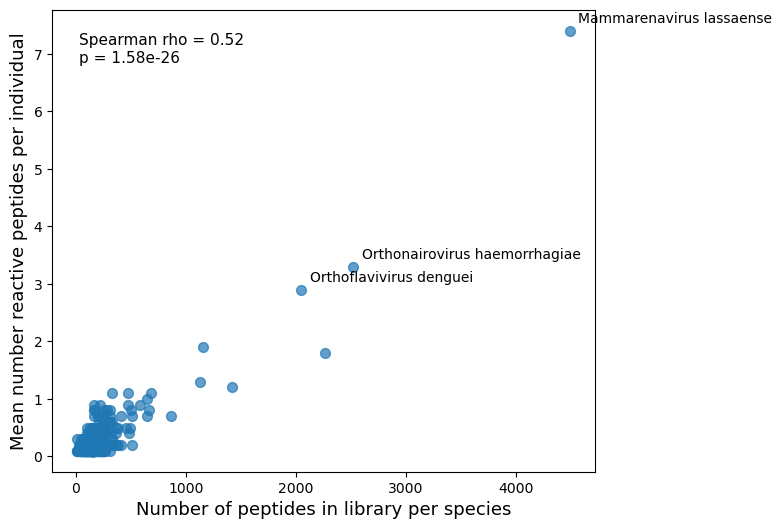

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr 

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    sl_only['number_peps_in_library'],
    sl_only['mean_cohort_reactive_species_peps'], 
    alpha=0.7, 
    s=50
)

rho, p_value = spearmanr(
    sl_only['number_peps_in_library'],
    sl_only['mean_cohort_reactive_species_peps']
)

ax.text(
    0.05, 0.95, 
    f'Spearman rho = {rho:.2f} \np = {p_value:.2e}', 
    transform = ax.transAxes,
    ha='left', 
    va='top', 
    fontsize=11

)
highlight = ['Mammarenavirus lassaense', 'Orthonairovirus haemorrhagiae', 'Orthoflavivirus denguei']

for _, row in sl_only.iterrows():
    if row['species'] in highlight:
        ax.annotate(
            row['species'], 
            (row['number_peps_in_library'], row['mean_cohort_reactive_species_peps']), 
            xytext=(6,6), 
            textcoords='offset points', 
            fontsize=10
        )

ax.set_xlabel('Number of peptides in library per species', fontsize=13)
ax.set_ylabel('Mean number reactive peptides per individual', fontsize=13)


plt.show()

### transforming relationship on a log scale log(1 + XXX) and fitting blue regression line. we do this as there are a few species with a lot of peptides, which leads to a skewed distribution. log transformation helps to compress large numbers while still preserving their order. and log1 allows zeros to be included, because log(0) is undefined. 

### the regression finds the line that best describes the relationship observed after log transformation. given each species's library representation, where would I predict its mean reactivity to fall? least squares is (observed - predicted)^2, and the algorithm squares every one of those distances and adds them together. Finally the algorithm chooses the slope and intercept that makes the total as small as possible. 

In [51]:
from scipy.stats import linregress
import numpy as np

sl_only['log_library_size'] = np.log1p(sl_only['number_peps_in_library'])

sl_only['log_mean_reactivity'] = np.log1p(sl_only['mean_cohort_reactive_species_peps'])

fit = linregress(
    sl_only['log_library_size'], 
    sl_only['log_mean_reactivity']
)

sl_only['expected_log_reactivity'] = (
    fit.intercept + fit.slope * sl_only['log_library_size']
)
sl_only['reactivity_residual'] = (
    sl_only['log_mean_reactivity'] - sl_only['expected_log_reactivity']
)

/tmp/ipykernel_1805397/2396581116.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sl_only['log_library_size'] = np.log1p(sl_only['number_peps_in_library'])
/tmp/ipykernel_1805397/2396581116.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sl_only['log_mean_reactivity'] = np.log1p(sl_only['mean_cohort_reactive_species_peps'])
/tmp/ipykernel_1805397/2396581116.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = val

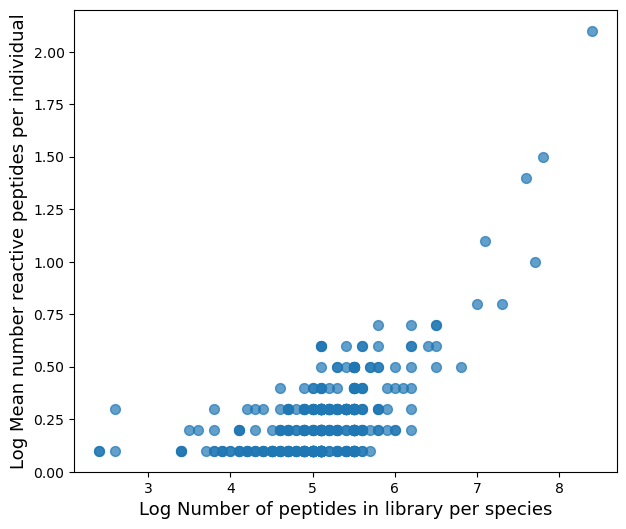

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr 

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    sl_only['log_library_size'].round(1), 
    sl_only['log_mean_reactivity'].round(1),
    alpha=0.7, 
    s=50
)

highlight = ['Mammarenavirus lassaense', 'Orthonairovirus haemorrhagiae', 'Orthoflavivirus denguei']

for _, row in sl_only.iterrows():
    if row['species'] in highlight:
        ax.annotate(
            row['species'], 
            (row['number_peps_in_library'], row['mean_cohort_reactive_species_peps']), 
            xytext=(6,6), 
            textcoords='offset points', 
            fontsize=10
        )

ax.set_xlabel('Log Number of peptides in library per species', fontsize=13)
ax.set_ylabel('Log Mean number reactive peptides per individual', fontsize=13)


plt.show()

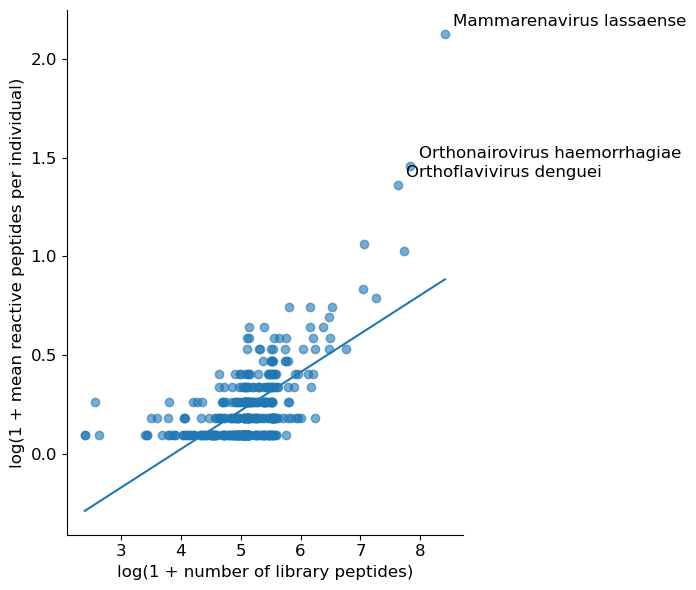

In [53]:
fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(sl_only['log_library_size'], sl_only['log_mean_reactivity'], alpha=0.6)

x = np.linspace(
    sl_only['log_library_size'].min(), sl_only['log_library_size'].max(), 200
)

y = fit.intercept + fit.slope * x

ax.plot(x, y)

ax.set_xlabel('log(1 + number of library peptides)', fontsize=12)
ax.set_ylabel('log(1 + mean reactive peptides per individual)', fontsize=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

highlight = ['Mammarenavirus lassaense', 'Orthonairovirus haemorrhagiae', 'Orthoflavivirus denguei']

for _, row in sl_only.iterrows():
    if row['species'] in highlight:
        ax.annotate(
            row['species'], 
            (row['log_library_size'], row['log_mean_reactivity']), 
            xytext=(6,6), 
            textcoords='offset points', 
            fontsize=12
        )

ax.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.savefig('species_reactive_peps_after_accounting_for_library.svg', format='svg')
plt.show()

/tmp/ipykernel_1805397/1009504264.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sl_only['fitted'] = fit.intercept + fit.slope * sl_only['log_library_size']


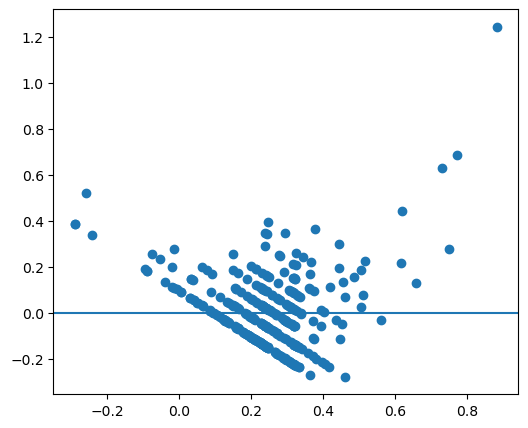

In [54]:
sl_only['fitted'] = fit.intercept + fit.slope * sl_only['log_library_size']

fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(
    sl_only['fitted'], 
    sl_only['reactivity_residual']
)

ax.axhline(0)

plt.show()

In [64]:
sl_only.sort_values(['reactivity_residual'], ascending=False).head(30)

,species,cohort,mean_cohort_reactive_species_peps,median_cohort_reactive_species_peps,max_cohort_individual_reactive_species_peps,sum_cohort_reactive_species_peps,number_peps_in_library,unique_reactive_peps_in_cohort,unique_reactive_peps_in_cohort_normalized_to_library,mean_perc_cohort_reactive_species_peps_normalized_to_library,log_library_size,log_mean_reactivity,expected_log_reactivity,reactivity_residual,fitted
181,Mammarenavirus lassaense,SL,7.4,7.0,27,2924,4494,76,1.7,0.2,8.410721,2.128232,0.883798,1.244433,0.883798
365,Orthonairovirus haemorrhagiae,SL,3.3,3.0,12,1327,2524,39,1.5,0.1,7.833996,1.458615,0.771206,0.687409,0.771206
269,Orthoflavivirus denguei,SL,2.9,3.0,11,1139,2050,32,1.6,0.1,7.626083,1.360977,0.730616,0.630361,0.730616
243,Mopeia Lassa virus reassortant 29,SL,0.3,0.0,1,119,12,1,8.3,2.5,2.564949,0.262364,-0.257456,0.519820,-0.257456
249,Nairoviridae sp.,SL,1.9,2.0,6,759,1160,20,1.7,0.2,7.057037,1.064711,0.619522,0.445188,0.619522
461,Phlebovirus ambeense,SL,0.9,1.0,5,340,170,7,4.1,0.5,5.141664,0.641854,0.245589,0.396265,0.245589
561,Phlebovirus sp. PAN 483391,SL,0.1,0.0,1,22,10,1,10.0,1.0,2.397895,0.095310,-0.290069,0.385379,-0.290069
15,Amga virus,SL,0.1,0.0,1,26,10,1,10.0,1.0,2.397895,0.095310,-0.290069,0.385379,-0.290069
391,Orthonairovirus nairobiense,SL,1.1,1.0,4,441,333,7,2.1,0.3,5.811141,0.741937,0.376290,0.365648,0.376290
39,Bandavirus dabieense,SL,0.9,1.0,2,346,217,3,1.4,0.4,5.384495,0.641854,0.292997,0.348857,0.292997


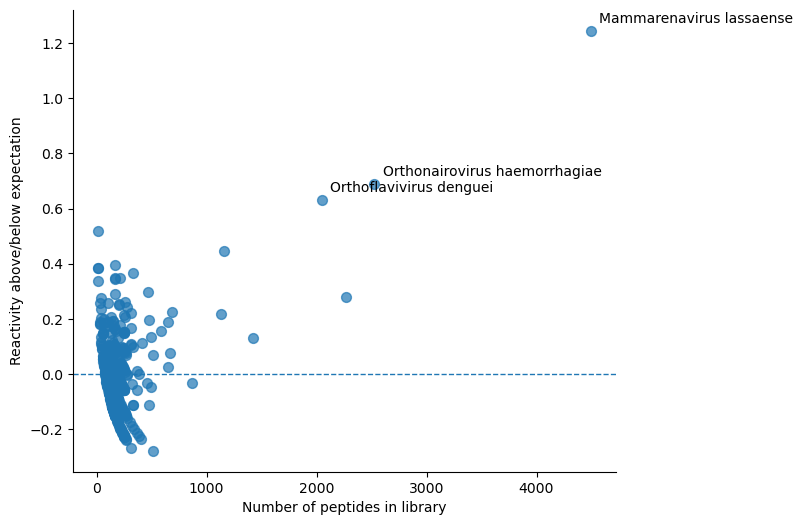

In [56]:
plot_df = sl_only.sort_values('reactivity_residual', ascending=False)

fig, ax = plt.subplots(figsize=(7, 6))

ax.scatter(
    plot_df['number_peps_in_library'], plot_df['reactivity_residual'], alpha=0.7, s=50
)

ax.axhline(0, linestyle='--', linewidth=1)

ax.set_xlabel('Number of peptides in library')
ax.set_ylabel('Reactivity above/below expectation')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for _, row in plot_df.iterrows():
    if row['species'] in highlight:
        ax.annotate(
            row['species'], 
            (row['number_peps_in_library'], row['reactivity_residual']), 
            xytext=(6,6), 
            textcoords='offset points', 
            fontsize=10
        )

plt.show()

## clustering peptides within genera to identify distinct viral reactivity regions rather than redundant peptide recognition.

## first with Crimean-Congo

## focusing on CCHFV and DENV

### first just sum reactive peptides for each individual per species and show in heatmap

In [57]:
df_cc = df.loc[df['species'] == 'Orthonairovirus haemorrhagiae']

df_denv = df.loc[df['species'] == 'Orthoflavivirus denguei']

df_concat = pd.concat([df_cc, df_denv], axis=0)

## figure or calculation showing that CCHFV reactivity is dominated by glycoprotein precursor peptide reactivities

In [58]:
cc_protein_sum = df_cc.groupby(['protein_std', 'cohort', 'individual']).agg(
    summed = ('reactive', 'sum')
).reset_index()

In [59]:
cc_protein_average = cc_protein_sum.groupby(['protein_std', 'cohort']).agg(
    mean = ('summed', 'mean')
).round(1).reset_index()

In [60]:
cc_library = meta.loc[meta['species'] == 'Orthonairovirus haemorrhagiae']
cc_library = cc_library[['protein_std', 'seq_id']].drop_duplicates().groupby('protein_std').size().reset_index(name='n_library_peptides')

In [61]:
cc_summary = cc_protein_average.query("cohort == 'SL'").merge(cc_library, on='protein_std')

cc_summary['perc_reactive'] = (cc_summary['mean'] / cc_summary['n_library_peptides']) * 100 

In [62]:
cc_summary['perc_reactive'] = cc_summary['perc_reactive'].round(2)

cc_summary

,protein_std,cohort,mean,n_library_peptides,perc_reactive
0,glycoprotein,SL,2.6,1877,0.14
1,nucleoprotein,SL,0.1,92,0.11
2,polymerase,SL,0.6,457,0.13


## sum reactive peptides per individual for CCHFV and DENV

In [63]:
df_concat_sum_peps_per_protein = df_concat.groupby(['individual', 'species', []]).agg(
    sum_reactive = ('reactive', 'sum')
).reset_index()

ValueError: Grouper and axis must be same length

In [ ]:
df_concat_sum_peps_per_protein

,individual,species,sum_reactive
0,C-109-1_5_B3,Orthoflavivirus denguei,1
1,C-109-1_5_B3,Orthonairovirus haemorrhagiae,3
2,C-109-2_5_B5,Orthoflavivirus denguei,3
3,C-109-2_5_B5,Orthonairovirus haemorrhagiae,4
4,C-109-3_4_E7,Orthoflavivirus denguei,3
...,...,...,...
963,S-512_SA3_G9,Orthonairovirus haemorrhagiae,5
964,S-513_SA3_I2,Orthoflavivirus denguei,1
965,S-513_SA3_I2,Orthonairovirus haemorrhagiae,4
966,S-514_SA3_C8,Orthoflavivirus denguei,2


In [ ]:
df_concat_wide = df_concat_sum_peps_per_protein.pivot(index='species', columns='individual', values='sum_reactive')

In [ ]:
c_cols = [col for col in df_concat_wide.columns if col.startswith('C-')]
s_cols = [col for col in df_concat_wide.columns if col.startswith('S-')]
hbdb_cols = [col for col in df_concat_wide.columns if col.startswith('HBDB-')]

ordered_cols = c_cols + s_cols + hbdb_cols

df_concat_wide = df_concat_wide[ordered_cols]

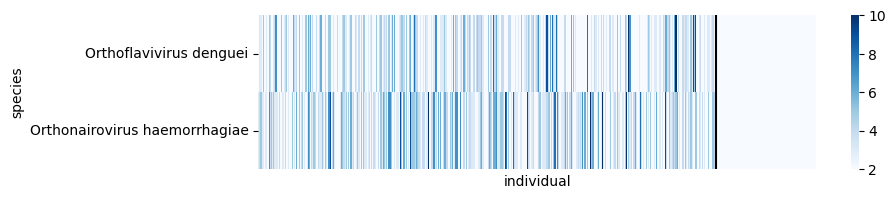

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 2))

ax = sns.heatmap(df_concat_wide, annot=False, cmap='Blues', vmin=2, vmax=10, xticklabels=False)

ax.axvline(x=len(c_cols + s_cols), color='black', linewidth=1.5)

plt.show()


## now focus on individual species with protein_std groups

In [ ]:
df_cc_sum_peps_per_protein = df_cc.groupby(['individual']).agg(
    sum_reactive = ('reactive', 'sum')
).reset_index()

In [ ]:
df_cc_sum_peps_per_protein = df_cc.groupby(['protein_std', 'individual']).agg(
    sum_reactive = ('reactive', 'sum')
).reset_index()

In [ ]:
df_cc_wide = df_cc_sum_peps_per_protein.pivot(index='protein_std', columns='individual', values='sum_reactive')

In [ ]:
c_cols = [col for col in df_cc_wide.columns if col.startswith('C-')]
s_cols = [col for col in df_cc_wide.columns if col.startswith('S-')]
hbdb_cols = [col for col in df_cc_wide.columns if col.startswith('HBDB-')]

ordered_cols = c_cols + s_cols + hbdb_cols

df_cc_wide = df_cc_wide[ordered_cols]

In [ ]:
df_cc_wide 

individual,C-109-1_5_B3,C-109-2_5_B5,C-109-3_4_E7,C-110-1_2_A5,C-110-2_3_F8,C-110-3_2_E6,C-111-1_2_H8,C-111-2_3_I5,C-111-3_3_I6,C-112-1_3_B3,...,HBDB-097,HBDB-098,HBDB-099,HBDB-100,HBDB-102,HBDB-106,HBDB-107,HBDB-109,HBDB-111,HBDB-115
protein_std,,,,,,,,,,,,,,,,,,,,,
glycoprotein,3,4,5,3,3,0,2,3,1,7,...,0,0,0,0,0,0,0,0,0,0
nucleoprotein,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
polymerase,0,0,0,0,0,1,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


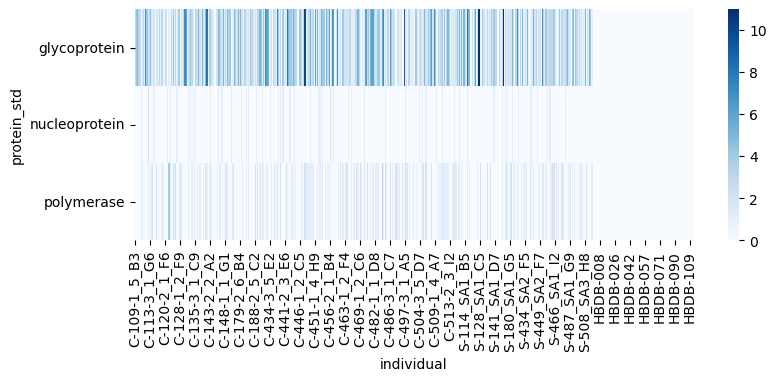

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 3))
sns.heatmap(df_cc_wide, annot=False, cmap='Blues')

plt.show()
